# Climate Forecasting as Support for Planting Calendar 

[Historical Weather 1940–2025] in bogor

(Forecasting Model)

[Predicted Weather for year]

(Rule-based / ML Classifier for Planting Suitability per Day) (from literature review)



## 01_EDA

In [30]:
%pip install pandas numpy matplotlib seaborn scipy statsmodels


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [32]:
plt.rcParams.update({
    'figure.dpi': 140,
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 10,
})
sns.set_theme(style='whitegrid', palette='bright')

DATASET_PATH = 'dataset/merged_dataset-1940-2025-bogor.csv'

In [33]:
df_raw = pd.read_csv(DATASET_PATH)
df_raw.head()

,time,weather_code (wmo code),temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),apparent_temperature_max (°C),sunrise (iso8601),sunset (iso8601),...,soil_temperature_0_to_100cm_mean (°C),soil_temperature_0_to_7cm_mean (°C),soil_temperature_28_to_100cm_mean (°C),soil_temperature_7_to_28cm_mean (°C),relative_humidity_2m_mean (%),relative_humidity_2m_max (%),relative_humidity_2m_min (%),surface_pressure_mean (hPa),pressure_msl_mean (hPa),dew_point_2m_mean (°C)
0,1940-01-02,63,23.6,27.5,21.2,25.2,28.4,33.9,1940-01-02T05:41,1940-01-02T18:11,...,25.3,25.2,25.3,25.1,94.0,99,81,983.8,1012.1,22.4
1,1940-01-03,63,23.5,27.9,21.4,25.3,27.5,32.9,1940-01-03T05:42,1940-01-03T18:11,...,25.3,25.1,25.3,25.2,89.0,98,72,983.2,1011.5,21.5
2,1940-01-04,55,23.0,25.6,21.2,24.5,26.4,28.6,1940-01-04T05:42,1940-01-04T18:12,...,25.1,24.1,25.3,24.8,90.0,96,77,982.8,1011.2,21.1
3,1940-01-05,63,23.8,29.1,20.4,23.3,27.4,35.0,1940-01-05T05:43,1940-01-05T18:12,...,25.1,24.8,25.3,24.7,85.0,97,65,982.0,1010.2,21.0
4,1940-01-06,63,23.6,28.6,20.5,23.4,27.9,34.6,1940-01-06T05:43,1940-01-06T18:13,...,25.2,25.2,25.3,25.0,89.0,98,72,981.4,1009.6,21.6


In [34]:
df_raw['time'] = pd.to_datetime(df_raw['time'])
df_raw['sunrise (iso8601)'] = pd.to_datetime(df_raw['sunrise (iso8601)'])
df_raw['sunset (iso8601)'] = pd.to_datetime(df_raw['sunset (iso8601)'])

df = df_raw.set_index('time').sort_index()

# Map WMO weather codes to descriptions
desc = pd.DataFrame(
    [
        {"Code": "0", "Description": "Cloud development not observed (Clear)"},
        {"Code": "1-3", "Description": "Clouds dissolving or changing"},
        {"Code": "10", "Description": "Mist"},
        {"Code": "45", "Description": "Fog, sky not visible"},
        {"Code": "51", "Description": "Light drizzle"},
        {"Code": "53", "Description": "Moderate drizzle"},
        {"Code": "55", "Description": "Dense drizzle"},
        {"Code": "61", "Description": "Slight rain"},
        {"Code": "63", "Description": "Moderate rain"},
        {"Code": "65", "Description": "Heavy rain"},
        {"Code": "71", "Description": "Slight snow"},
        {"Code": "73", "Description": "Moderate snow"},
        {"Code": "75", "Description": "Heavy snow"},
        {"Code": "80", "Description": "Light rain shower"},
        {"Code": "95", "Description": "Thunderstorm"},
    ]
)


def map_wmo_code(code):
    if pd.isna(code):
        return np.nan

    code = int(code)
    if code == 0:
        return "Cloud development not observed (Clear)"
    if 1 <= code <= 3:
        return "Clouds dissolving or changing"
    if code == 10:
        return "Mist"
    if code == 45:
        return "Fog, sky not visible"
    if code == 51:
        return "Light drizzle"
    if code == 53:
        return "Moderate drizzle"
    if code == 55:
        return "Dense drizzle"
    if code == 61:
        return "Slight rain"
    if code == 63:
        return "Moderate rain"
    if code == 65:
        return "Heavy rain"
    if code == 71:
        return "Slight snow"
    if code == 73:
        return "Moderate snow"
    if code == 75:
        return "Heavy snow"
    if code == 80:
        return "Light rain shower"
    if code == 95:
        return "Thunderstorm"
    return "Other"


df['weather_code (wmo code)'] = df['weather_code (wmo code)'].apply(map_wmo_code)
df['weather_code (wmo code)'] = pd.Categorical(
    df['weather_code (wmo code)'],
    categories=desc['Description'].tolist() + ['Other']
)

df.head()

,weather_code (wmo code),temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),apparent_temperature_max (°C),sunrise (iso8601),sunset (iso8601),daylight_duration (s),...,soil_temperature_0_to_100cm_mean (°C),soil_temperature_0_to_7cm_mean (°C),soil_temperature_28_to_100cm_mean (°C),soil_temperature_7_to_28cm_mean (°C),relative_humidity_2m_mean (%),relative_humidity_2m_max (%),relative_humidity_2m_min (%),surface_pressure_mean (hPa),pressure_msl_mean (hPa),dew_point_2m_mean (°C)
time,,,,,,,,,,,,,,,,,,,,,
1940-01-02,Moderate rain,23.6,27.5,21.2,25.2,28.4,33.9,1940-01-02 05:41:00,1940-01-02 18:11:00,44979.09,...,25.3,25.2,25.3,25.1,94.0,99,81,983.8,1012.1,22.4
1940-01-03,Moderate rain,23.5,27.9,21.4,25.3,27.5,32.9,1940-01-03 05:42:00,1940-01-03 18:11:00,44972.92,...,25.3,25.1,25.3,25.2,89.0,98,72,983.2,1011.5,21.5
1940-01-04,Dense drizzle,23.0,25.6,21.2,24.5,26.4,28.6,1940-01-04 05:42:00,1940-01-04 18:12:00,44966.27,...,25.1,24.1,25.3,24.8,90.0,96,77,982.8,1011.2,21.1
1940-01-05,Moderate rain,23.8,29.1,20.4,23.3,27.4,35.0,1940-01-05 05:43:00,1940-01-05 18:12:00,44959.16,...,25.1,24.8,25.3,24.7,85.0,97,65,982.0,1010.2,21.0
1940-01-06,Moderate rain,23.6,28.6,20.5,23.4,27.9,34.6,1940-01-06 05:43:00,1940-01-06 18:13:00,44951.59,...,25.2,25.2,25.3,25.0,89.0,98,72,981.4,1009.6,21.6


In [35]:
# --- Missing values ---
missing = df.isnull().sum().rename('null_count')
missing_pct = (missing / len(df) * 100).rename('null_pct')
mv_df = pd.concat([missing, missing_pct], axis=1)
print('=== Missing Values')
print(mv_df[mv_df['null_count'] > 0] if mv_df['null_count'].any() else 'No missing values')

# --- Duplicated value
duplicated_count = df.duplicated().sum()
print(f'\n=== Duplicated Values\nTotal duplicated rows: {duplicated_count}')
if duplicated_count > 0:
    print(df[df.duplicated()])

# --- Hari hilang ---
full_idx = pd.date_range(df.index.min(), df.index.max(), freq='D')
missing_dates = full_idx.difference(df.index)
print('\n=== Gap Tanggal')
print(f'Days (1940 - 2025) : {len(full_idx)}')
print(f'Days in dataset    : {len(df)}')
print(f'Missing dates      : {len(missing_dates)}')
if len(missing_dates):
    print(missing_dates)
    
# at first, we encounter missing dates from 1959-01-02 to 1959-12-31

=== Missing Values
No missing values

=== Duplicated Values
Total duplicated rows: 0

=== Gap Tanggal
Days (1940 - 2025) : 31411
Days in dataset    : 31411
Missing dates      : 0


In [36]:
numeric_df = df.select_dtypes(include=[np.number])
desc = numeric_df.describe().T
desc['skewness'] = numeric_df.apply(lambda c: c.skew())
desc['kurtosis'] = numeric_df.apply(lambda c: c.kurtosis())
desc.round(4)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
temperature_2m_mean (°C),31411.0,24.7805,0.9219,21.600,24.200,24.700,25.300,29.700,0.6396,0.8677
temperature_2m_max (°C),31411.0,29.1366,1.5329,23.200,28.300,29.100,29.900,37.500,0.4988,2.1531
temperature_2m_min (°C),31411.0,21.4001,1.0153,15.100,20.800,21.500,22.100,25.000,-0.4723,1.1806
apparent_temperature_min (°C),31411.0,25.0121,1.5013,15.400,24.200,25.200,26.000,29.700,-0.6976,1.3867
apparent_temperature_mean (°C),31411.0,29.1549,1.0507,23.300,28.500,29.200,29.900,33.400,-0.0837,0.2314
apparent_temperature_max (°C),31411.0,34.5765,1.8179,26.200,33.600,34.700,35.800,41.300,-0.5217,0.7054
daylight_duration (s),31411.0,43598.5270,950.3370,42264.360,42668.800,43562.030,44524.100,45014.580,0.0639,-1.4508
sunshine_duration (s),31411.0,35163.0838,8839.2491,0.000,31926.995,38552.410,41431.825,44086.180,-1.7972,3.1936
precipitation_sum (mm),31411.0,7.1409,7.9396,0.000,1.300,4.800,10.600,127.400,2.5885,15.5965
rain_sum (mm),31411.0,7.1409,7.9396,0.000,1.300,4.800,10.600,127.400,2.5885,15.5965


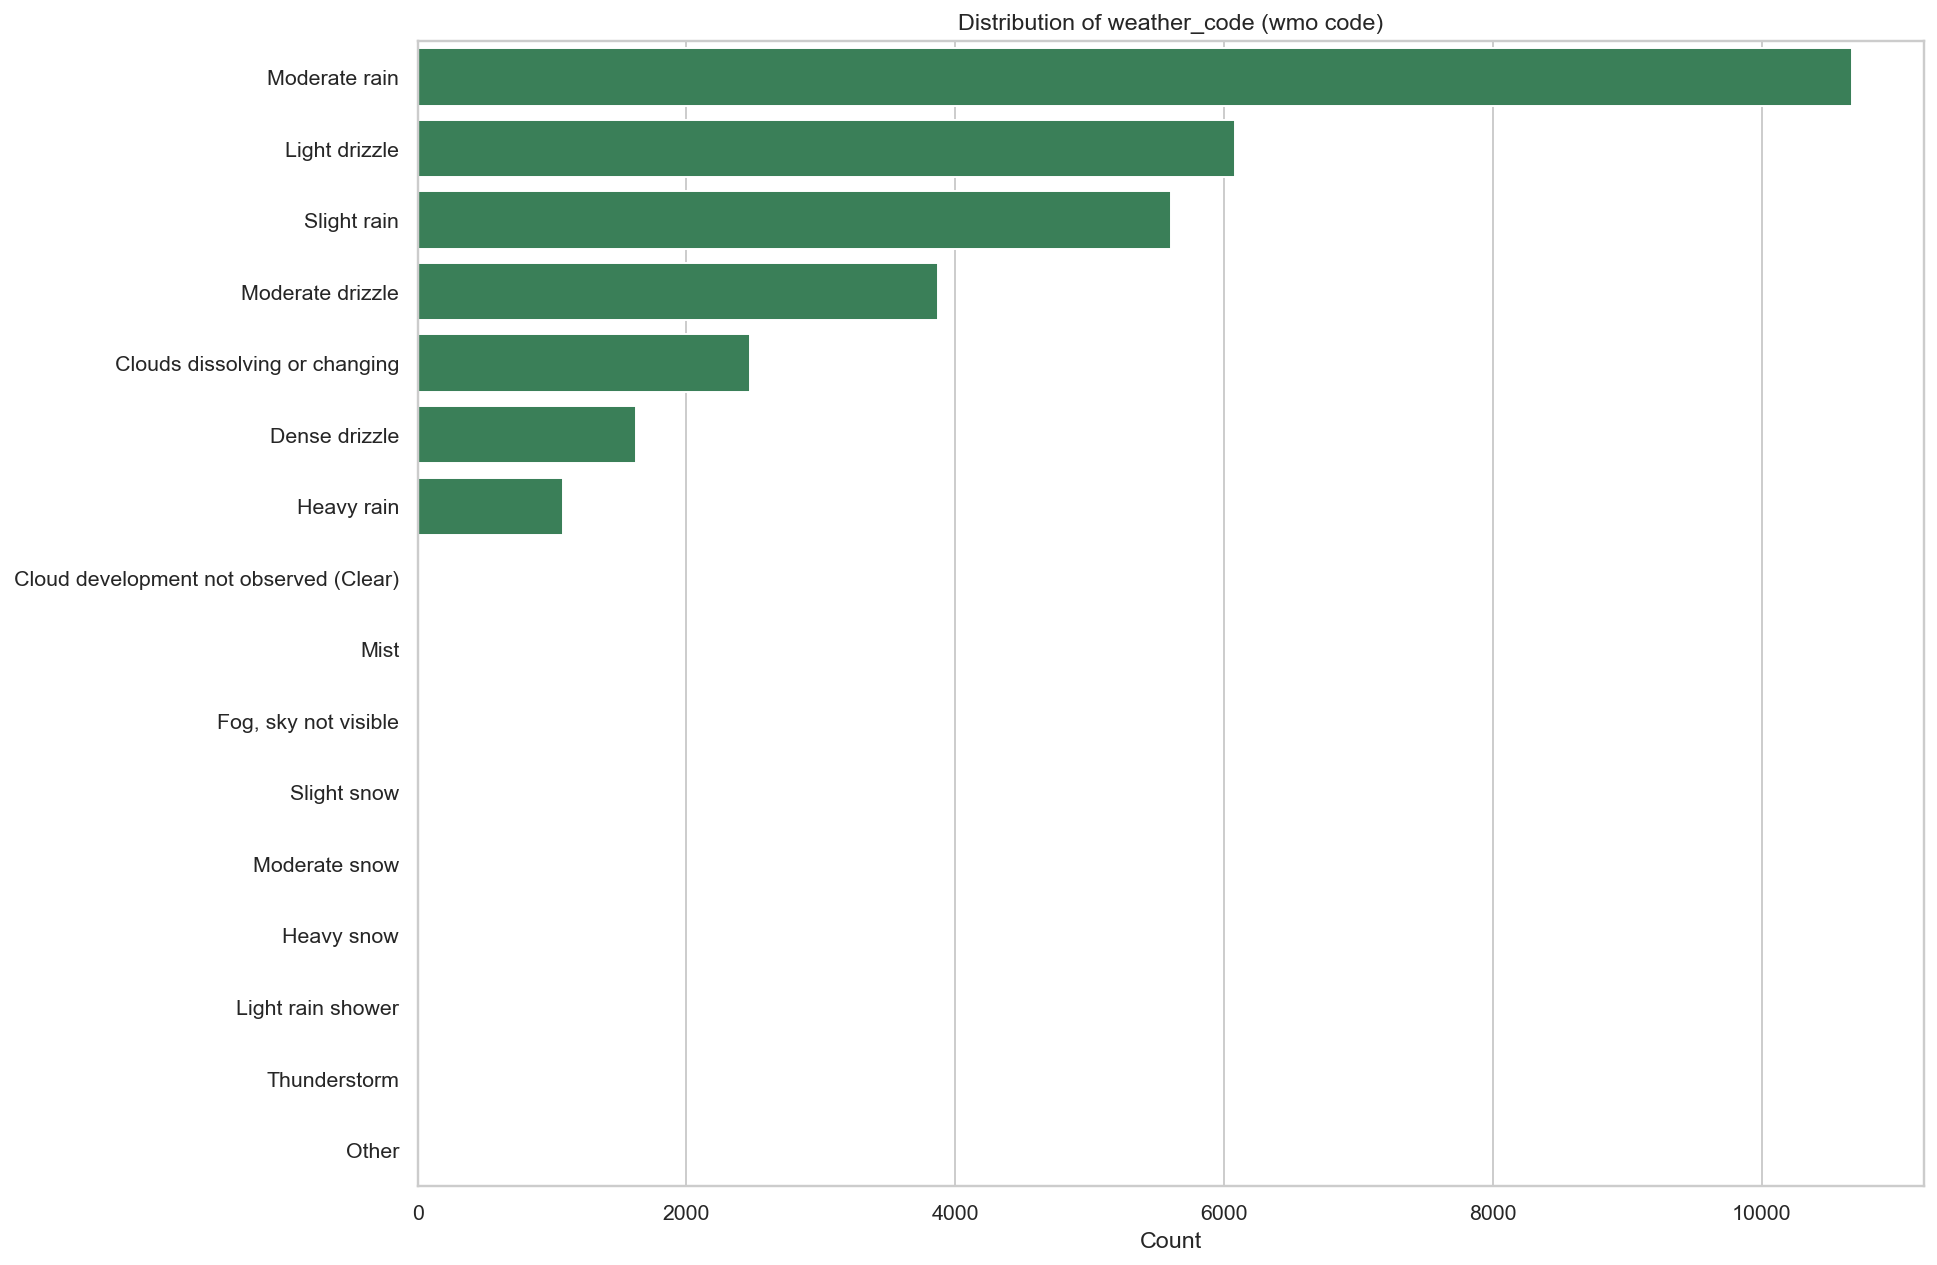

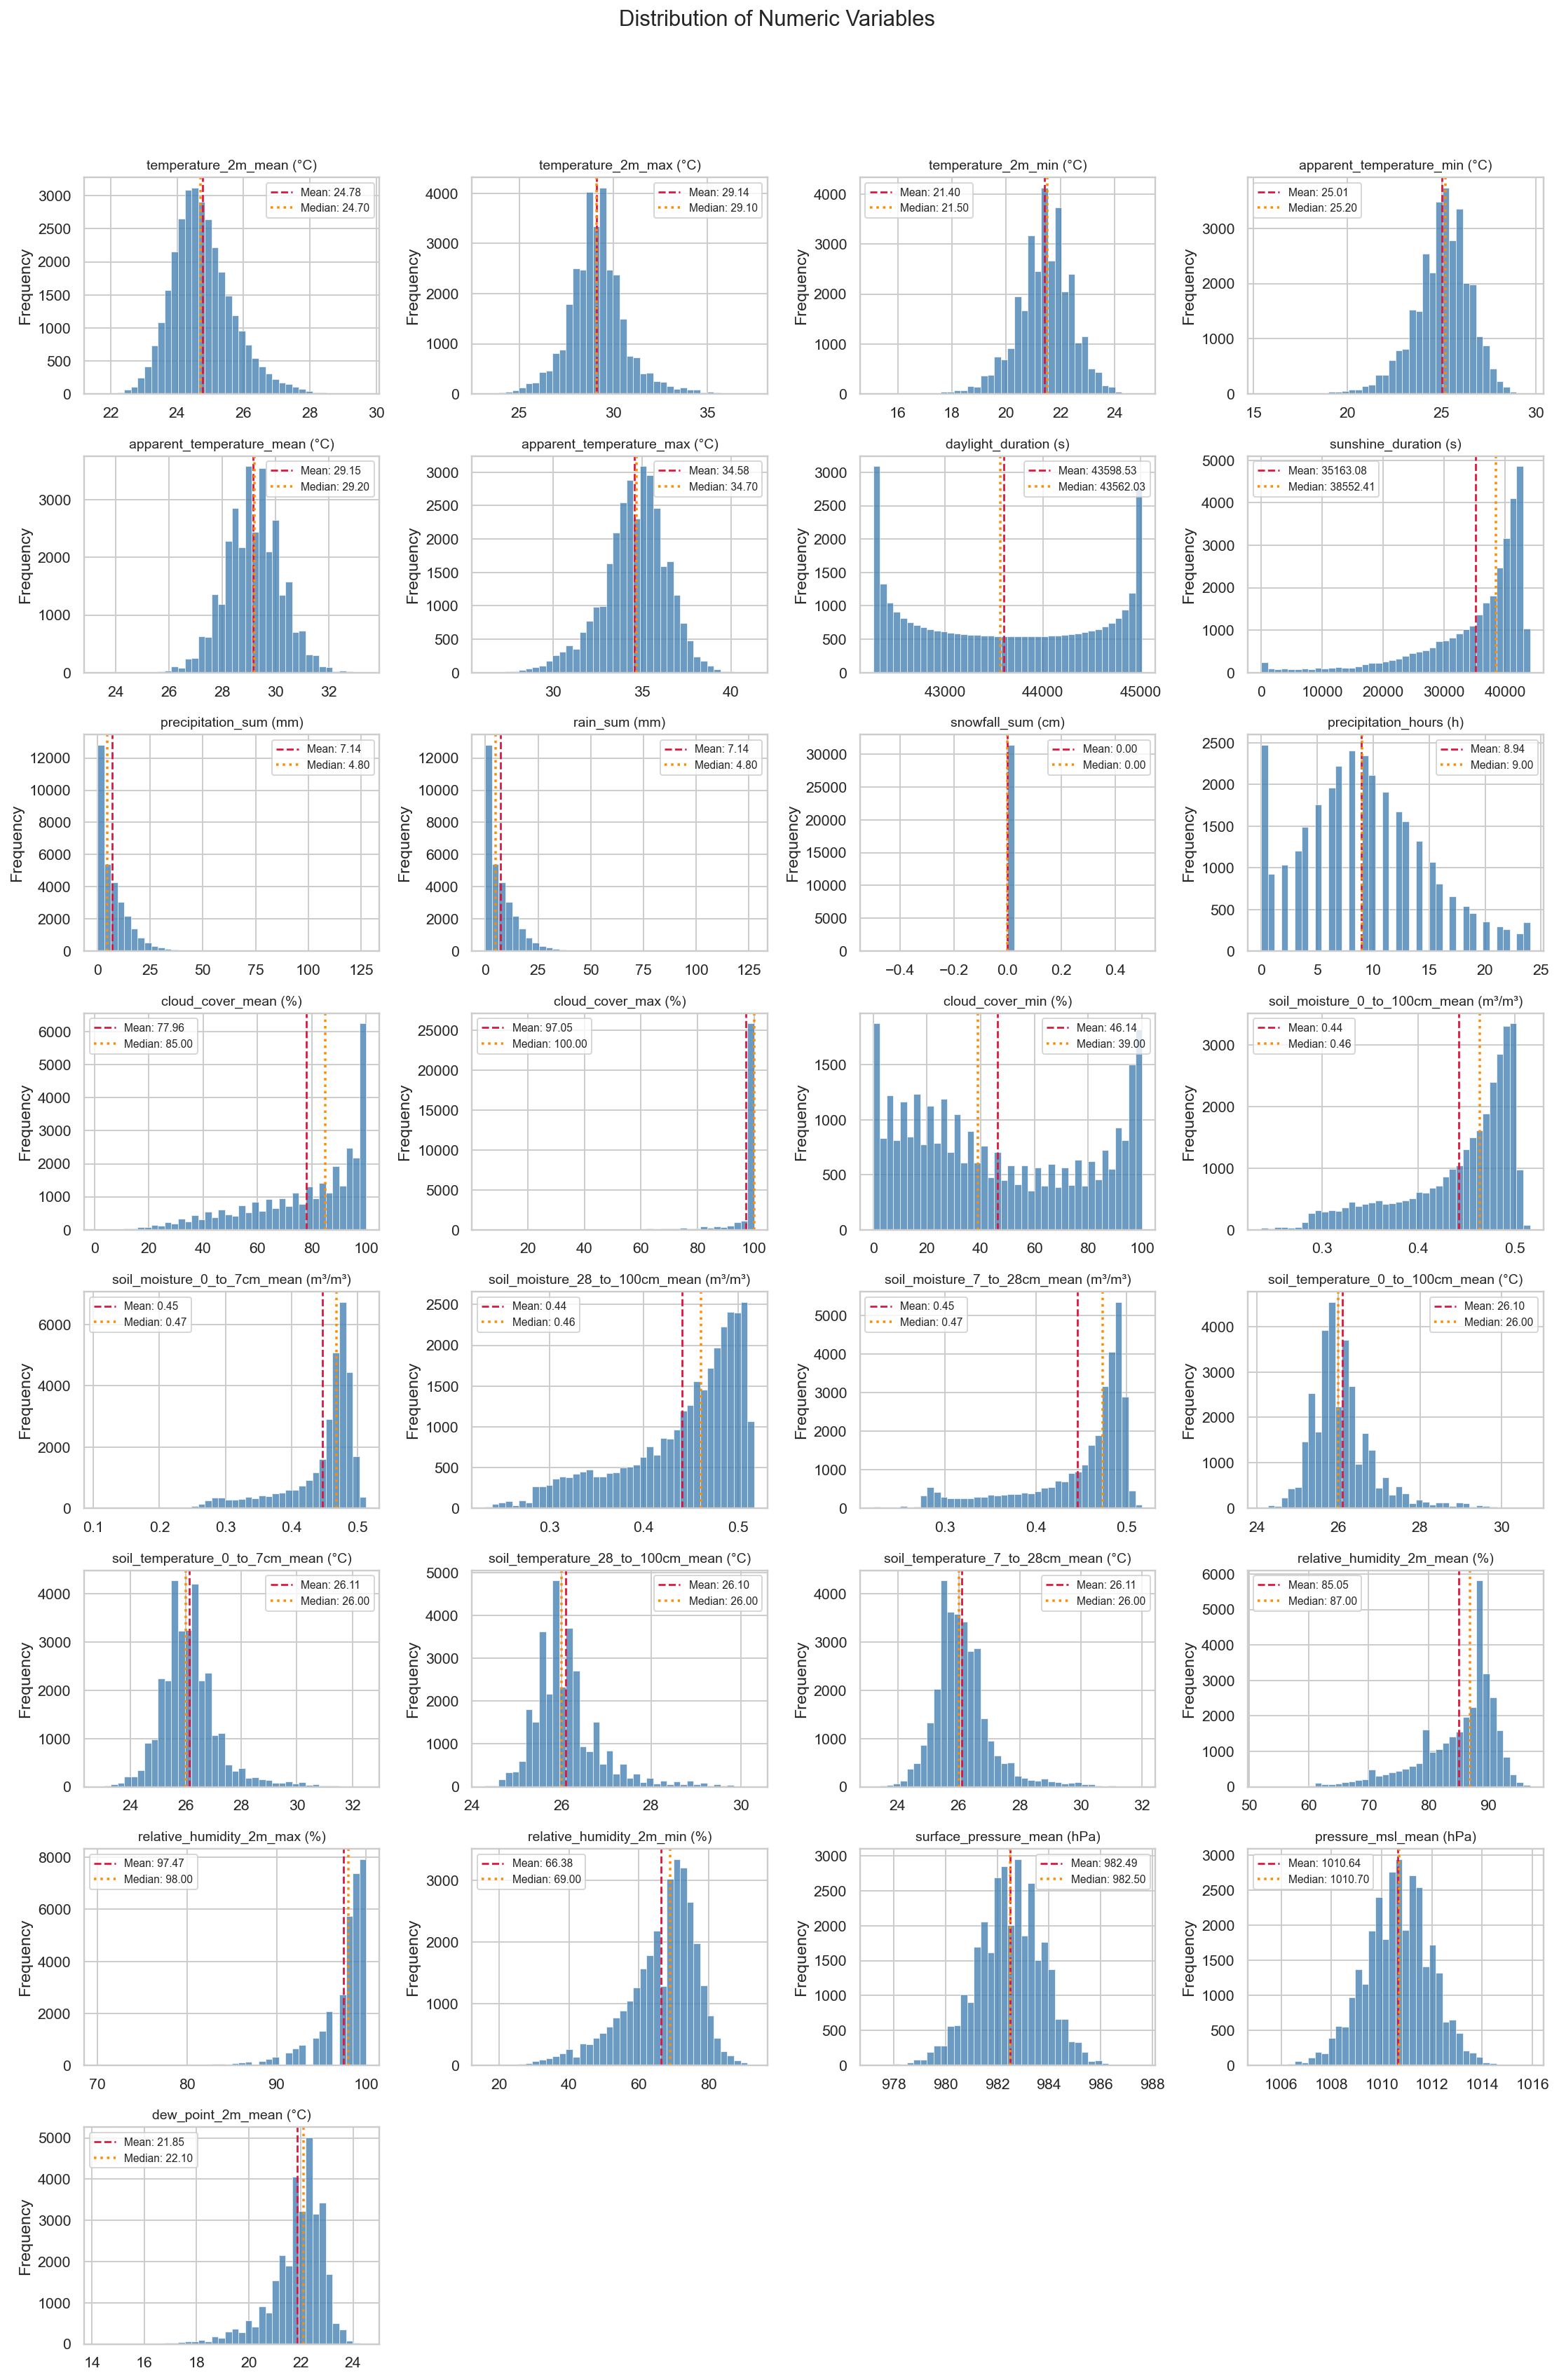

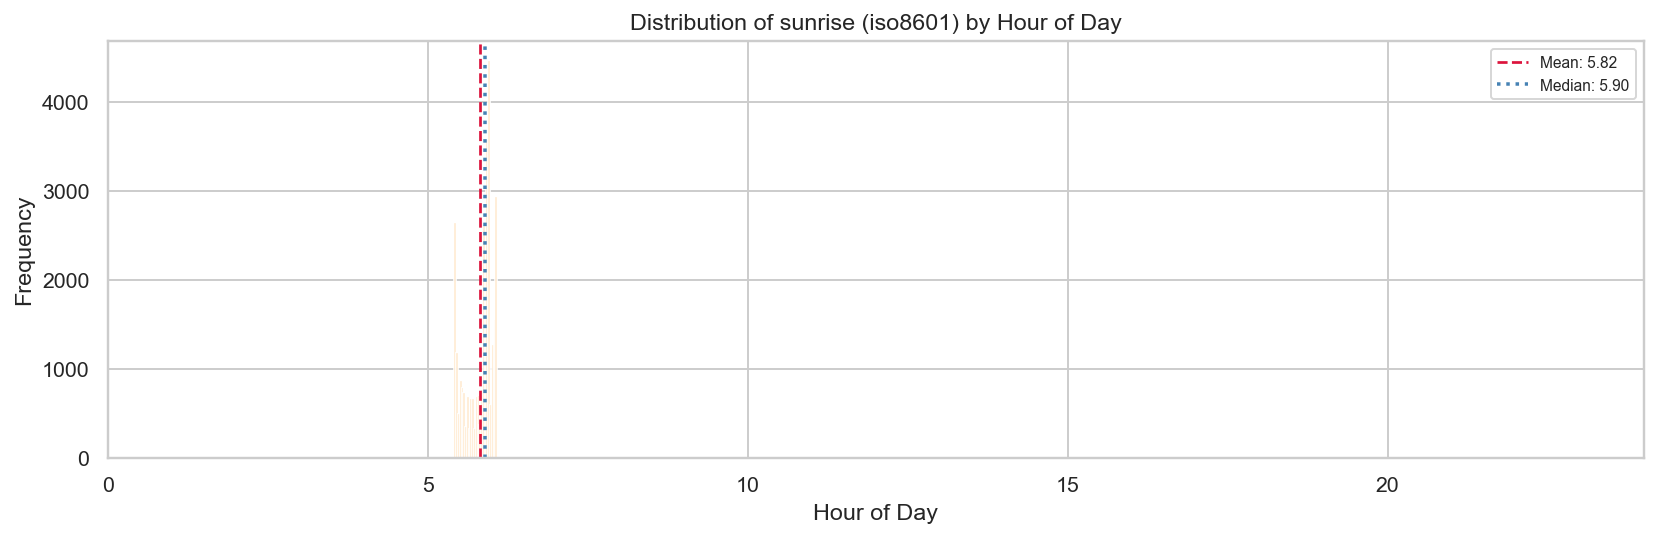

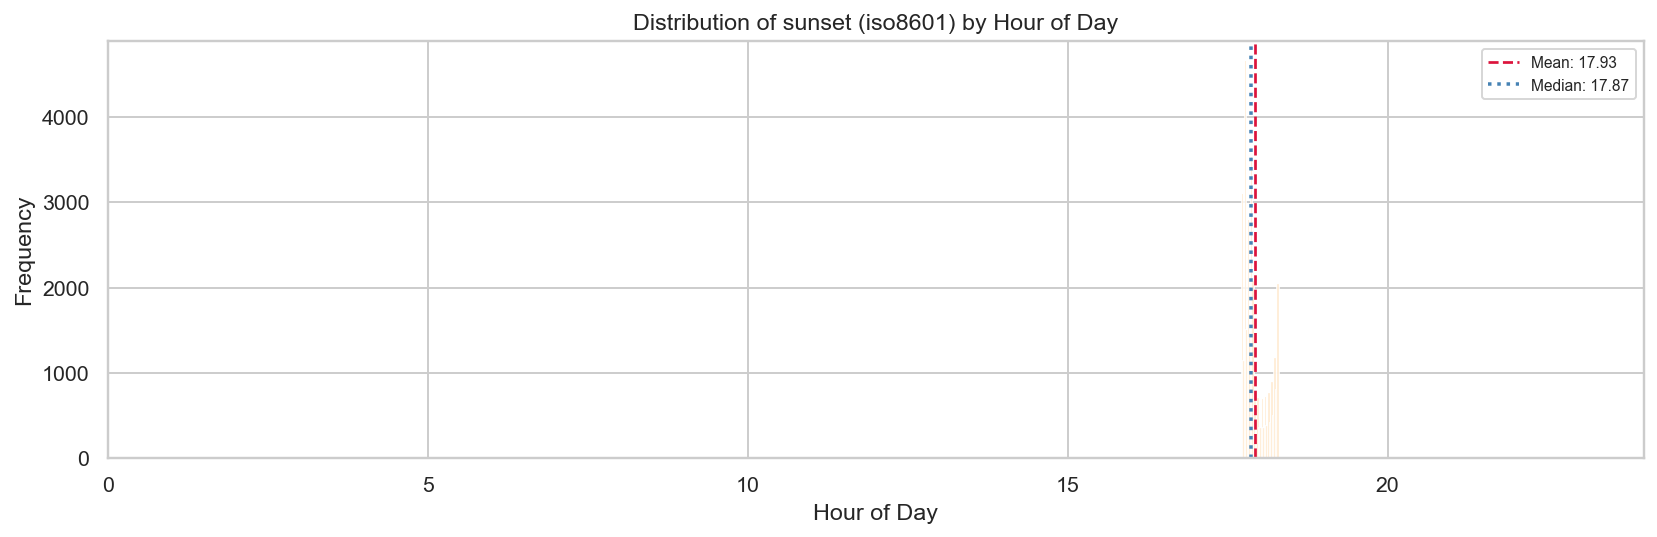

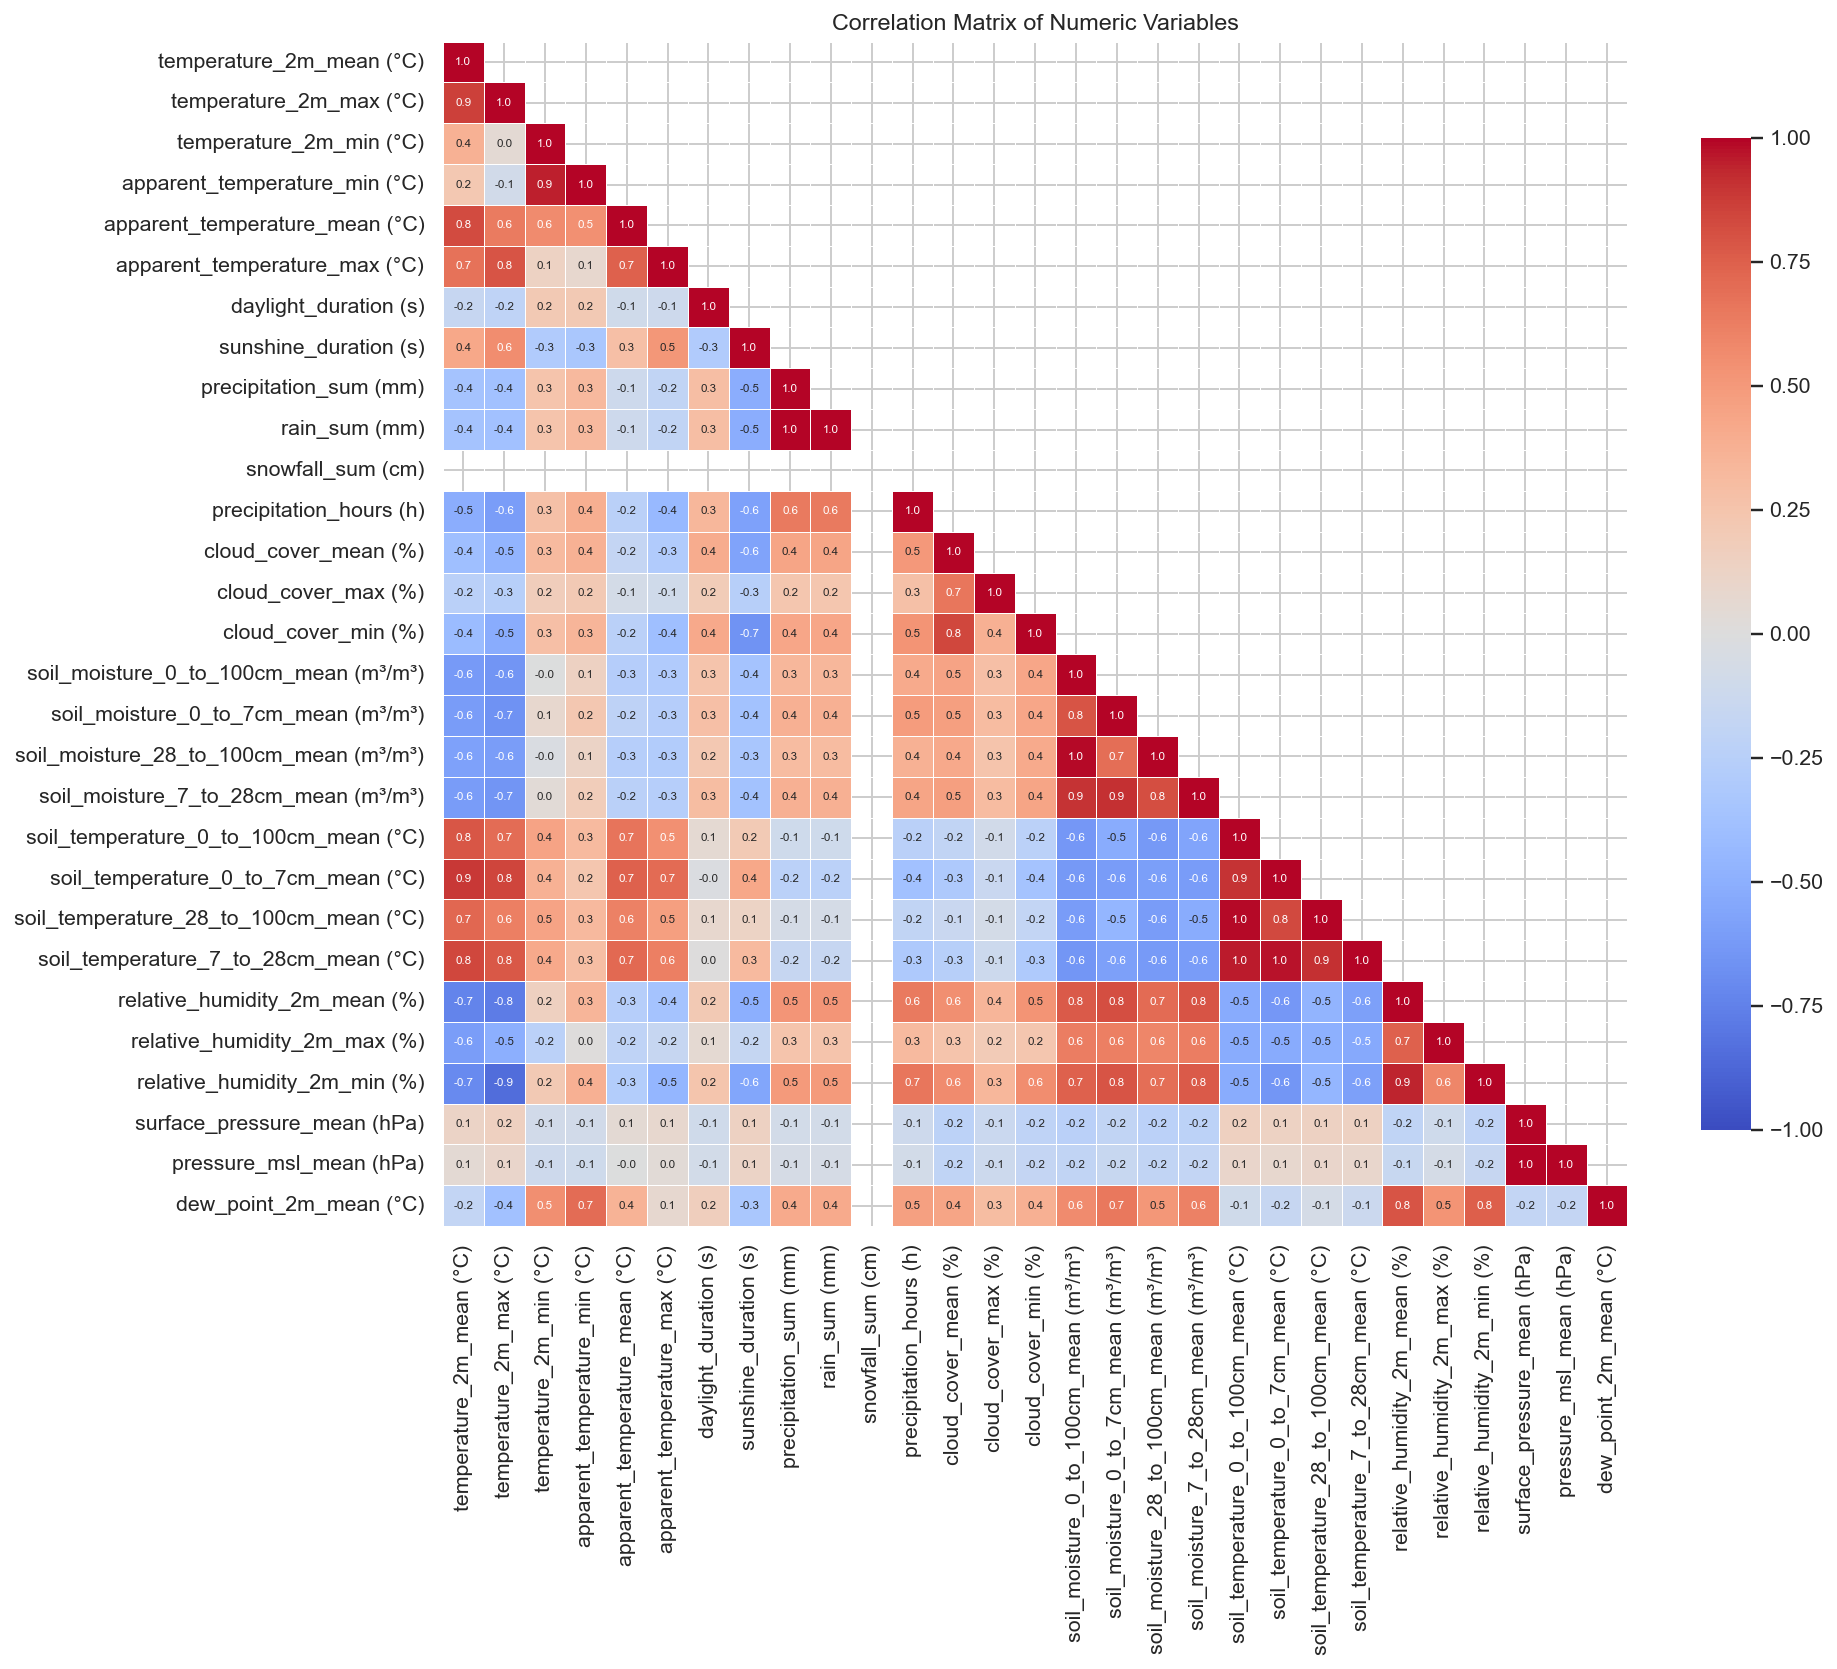

In [37]:
# Plot distributions for all variables by data type
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
datetime_cols = [column for column in df.columns if pd.api.types.is_datetime64_any_dtype(df[column])]
categorical_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()

for column in categorical_cols:
    order = df[column].value_counts().index

    fig, ax = plt.subplots(figsize=(14, max(5, 0.45 * len(order) + 2)))
    sns.countplot(data=df, y=column, order=order, ax=ax, color='seagreen')
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    fig.tight_layout()
    plt.show()

if numeric_cols:
    cols_per_row = 4
    n_rows = int(np.ceil(len(numeric_cols) / cols_per_row))
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 4, n_rows * 3))
    axes = np.atleast_1d(axes).ravel()

    for ax, column in zip(axes, numeric_cols):
        values = df[column].dropna()
        mean_value = values.mean()
        median_value = values.median()

        ax.hist(values, bins=40, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.4)
        ax.axvline(mean_value, color='crimson', linestyle='--', linewidth=1.4, label=f'Mean: {mean_value:.2f}')
        ax.axvline(median_value, color='darkorange', linestyle=':', linewidth=1.8, label=f'Median: {median_value:.2f}')
        ax.set_title(column, fontsize=10)
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)

    for ax in axes[len(numeric_cols):]:
        ax.axis('off')

    fig.suptitle('Distribution of Numeric Variables', fontsize=16, y=1.01)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

for column in datetime_cols:
    values = df[column].dropna()
    hour_values = values.dt.hour + values.dt.minute / 60
    mean_value = hour_values.mean()
    median_value = hour_values.median()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.hist(hour_values, bins=24, color='darkorange', alpha=0.85, edgecolor='white')
    ax.axvline(mean_value, color='crimson', linestyle='--', linewidth=1.4, label=f'Mean: {mean_value:.2f}')
    ax.axvline(median_value, color='steelblue', linestyle=':', linewidth=1.8, label=f'Median: {median_value:.2f}')
    ax.set_title(f'Distribution of {column} by Hour of Day')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Frequency')
    ax.set_xlim(0, 24)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

if numeric_cols:
    corr_matrix = df[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        cmap='coolwarm',
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt='.1f',
        annot_kws={'size': 6},
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8},
        ax=ax,
    )
    ax.set_title('Correlation Matrix of Numeric Variables')
    fig.tight_layout()
    plt.show()



=== Outliers Detection (IQR Method)
                                    column  outliers_count  \
0                 temperature_2m_mean (°C)             833   
1                  temperature_2m_max (°C)            1637   
2                  temperature_2m_min (°C)             518   
3            apparent_temperature_min (°C)             689   
4           apparent_temperature_mean (°C)             336   
5            apparent_temperature_max (°C)             875   
6                    daylight_duration (s)               0   
7                    sunshine_duration (s)            1815   
8                   precipitation_sum (mm)            1056   
9                            rain_sum (mm)            1056   
10                       snowfall_sum (cm)               0   
11                 precipitation_hours (h)               0   
12                    cloud_cover_mean (%)             114   
13                     cloud_cover_max (%)            5573   
14                     cloud_cove

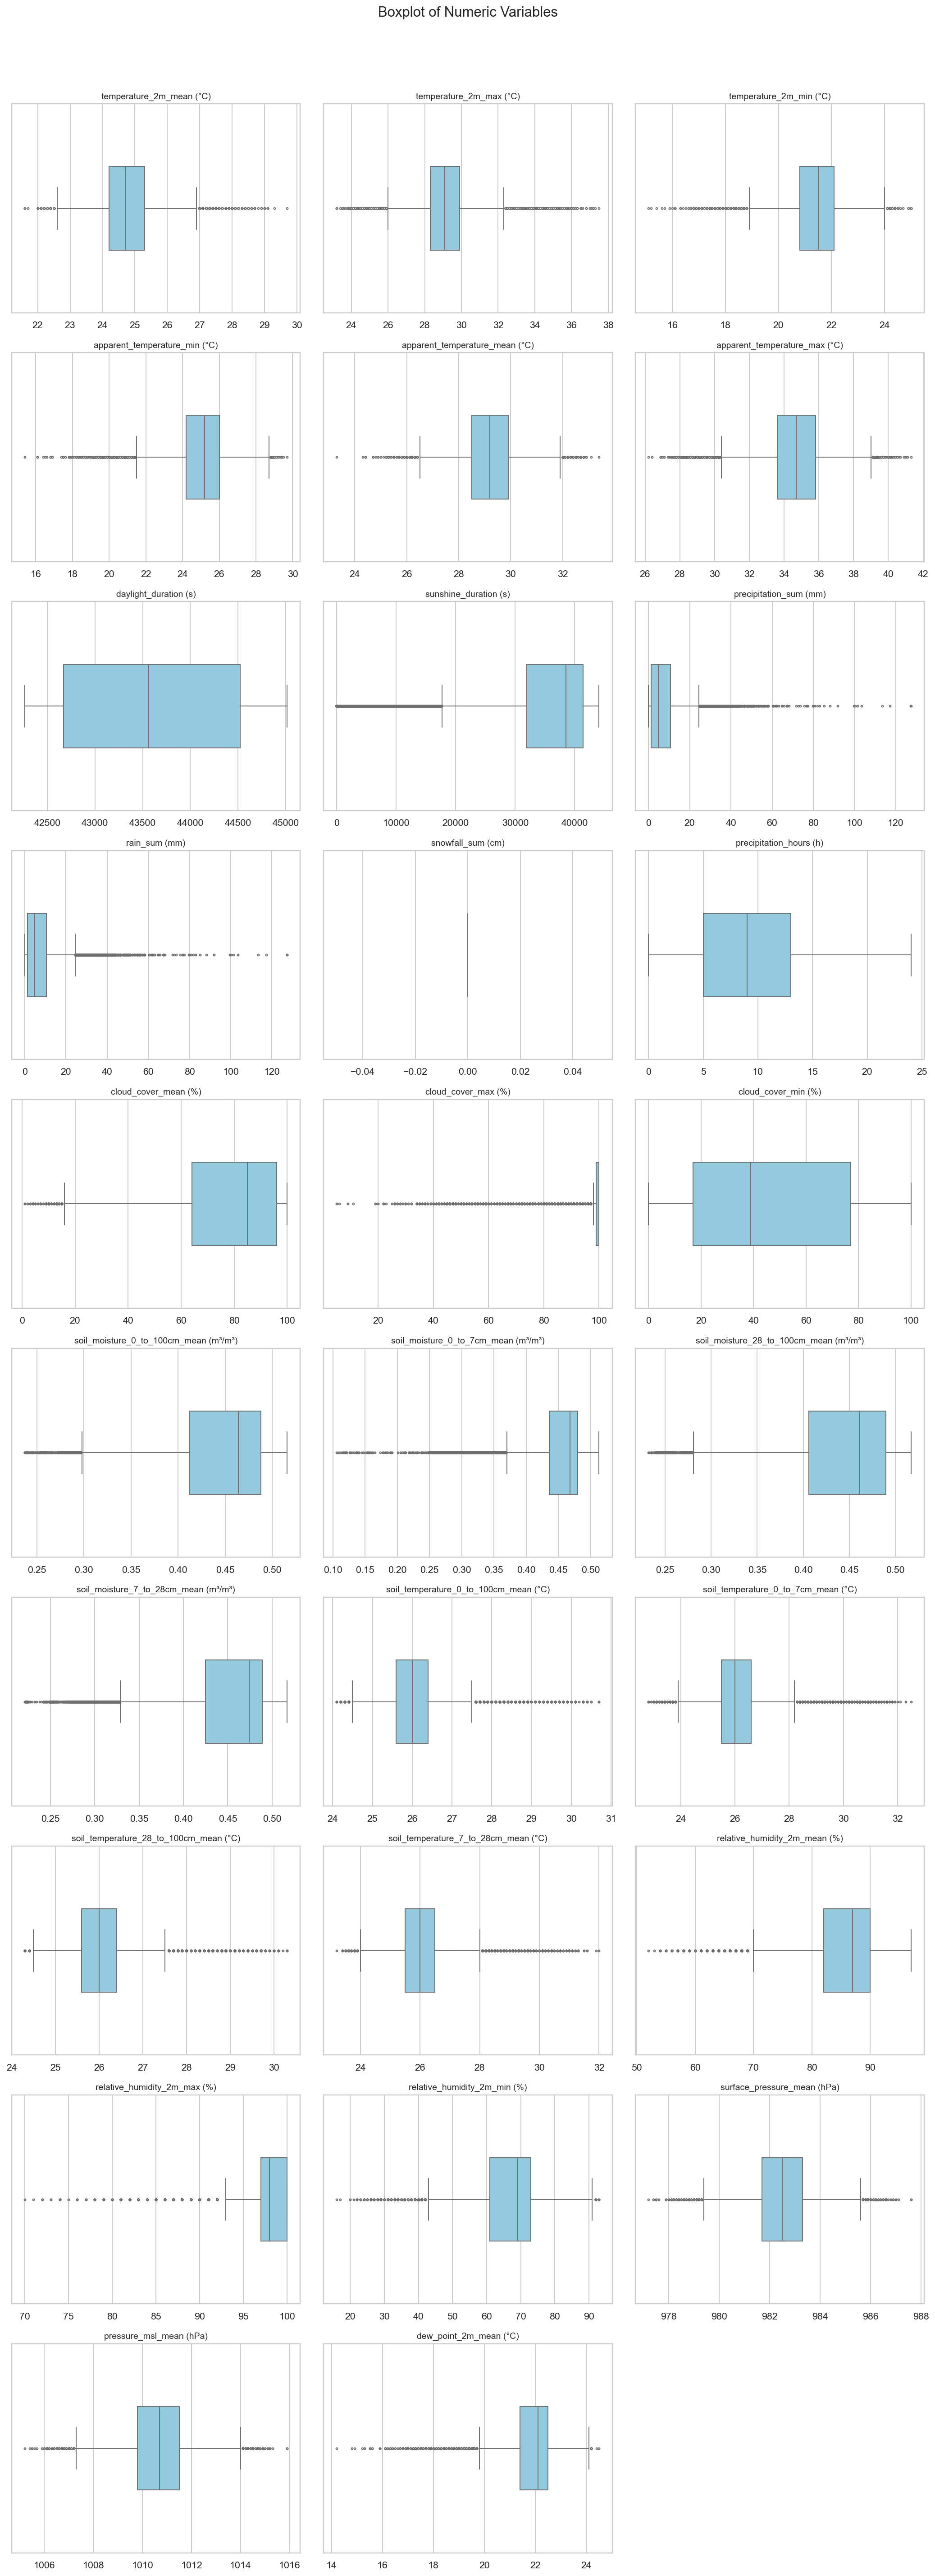

In [38]:
# --- Outliers Detection ---
outliers_info = []
for column in numeric_cols:
    values = df[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = values[(values < lower_bound) | (values > upper_bound)]
    outliers_info.append({
        'column': column,
        'outliers_count': len(outliers),
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers_percentage': (len(outliers) / len(values) * 100) if len(values) > 0 else 0
    })
    
outliers_df = pd.DataFrame(outliers_info)
print('\n=== Outliers Detection (IQR Method)')
print(outliers_df[['column', 'outliers_count', 'outliers_percentage']])

# --- Boxplot Visualization ---
if numeric_cols:
    plot_cols = numeric_cols
    cols_per_row = 3
    n_rows = int(np.ceil(len(plot_cols) / cols_per_row))
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 5, n_rows * 4))
    axes = np.atleast_1d(axes).ravel()

    for ax, column in zip(axes, plot_cols):
        values = df[column].dropna()
        sns.boxplot(x=values, ax=ax, color='skyblue', width=0.4, fliersize=2)
        ax.set_title(column, fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('')

    for ax in axes[len(plot_cols):]:
        ax.axis('off')

    fig.suptitle('Boxplot of Numeric Variables', fontsize=16, y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print('No numeric columns available for boxplot.')

=== Key Variables ===
- temperature_2m_mean (°C)
- temperature_2m_max (°C)
- temperature_2m_min (°C)
- precipitation_sum (mm)
- soil_moisture_0_to_100cm_mean (m³/m³) (root-zone soil moisture proxy)

=== Modeling Decision ===
Use monthly aggregation for forecasting. Daily data is used only for aggregation and quality checks.

=== Long-term Trend Summary (Annual Series) ===


,variable,slope_per_year,slope_per_decade,r_value,p_value
0,temperature_2m_mean (°C),0.014688,0.146880,0.703430,0.000000
1,temperature_2m_max (°C),0.012259,0.122589,0.498979,0.000001
2,temperature_2m_min (°C),0.019003,0.190028,0.861542,0.000000
3,precipitation_sum (mm),5.609357,56.093570,0.271546,0.011436
4,soil_moisture_0_to_100cm_mean (m³/m³),-0.000154,-0.001538,-0.121455,0.265290


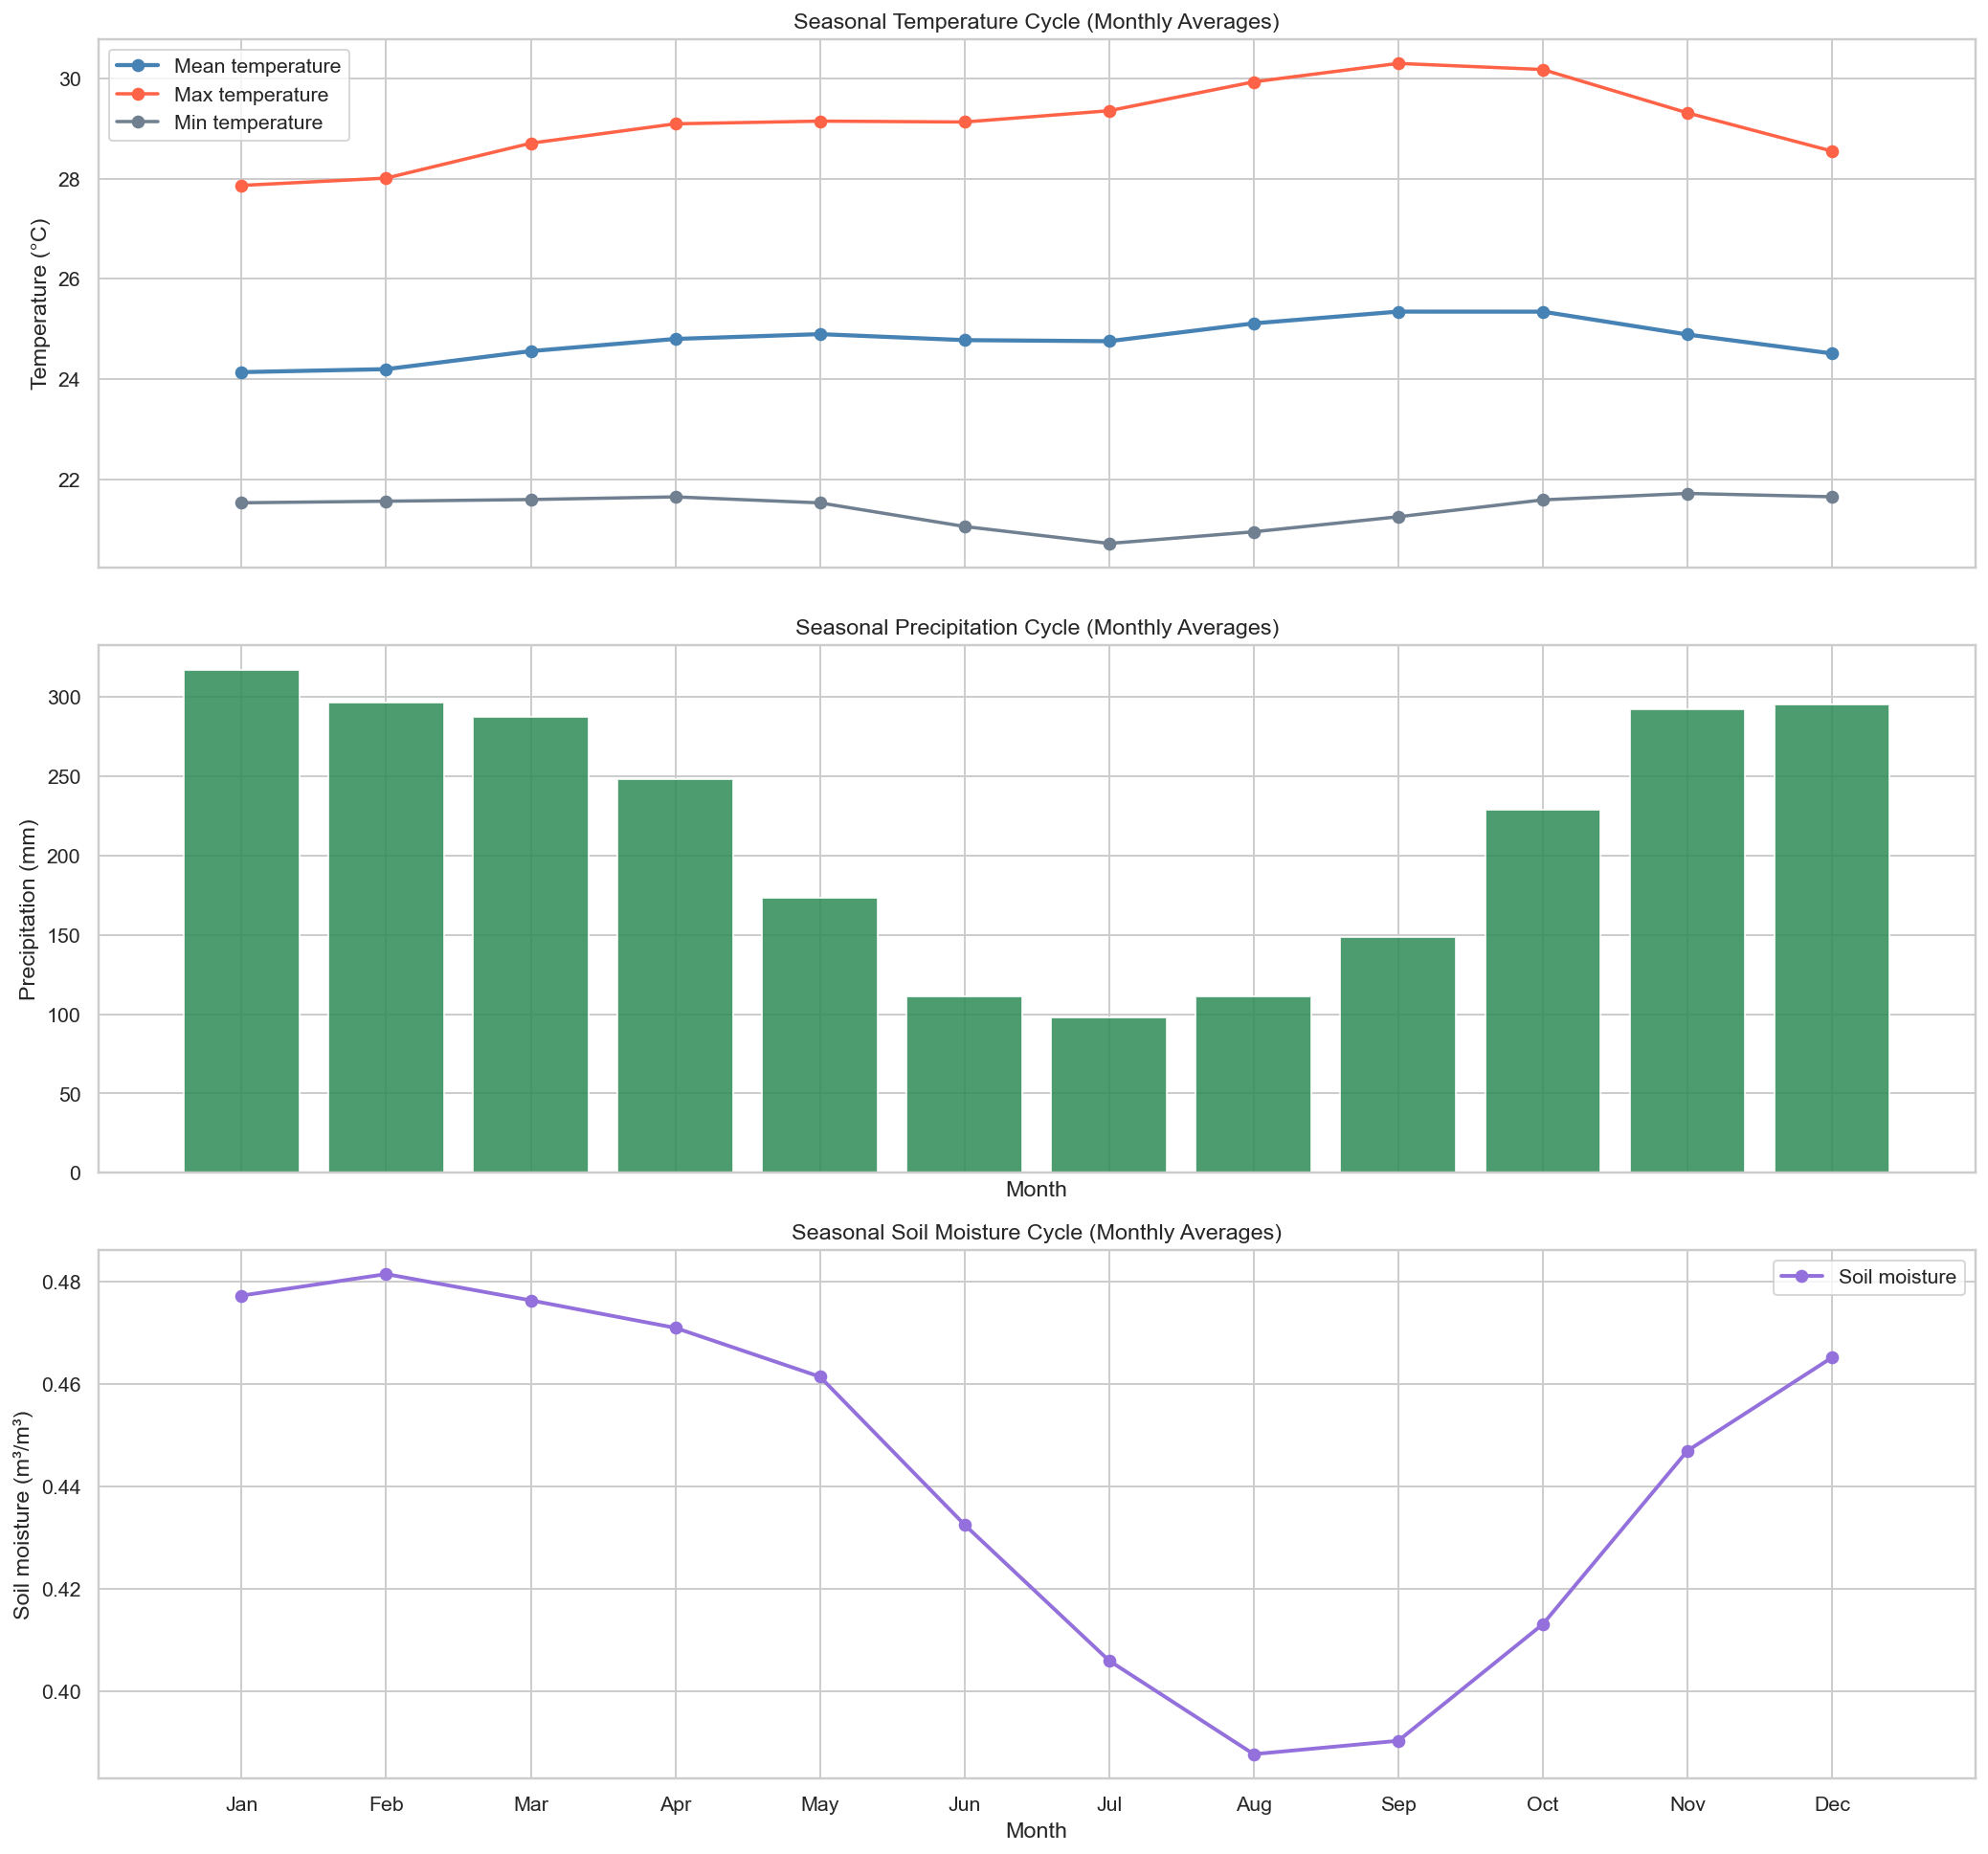

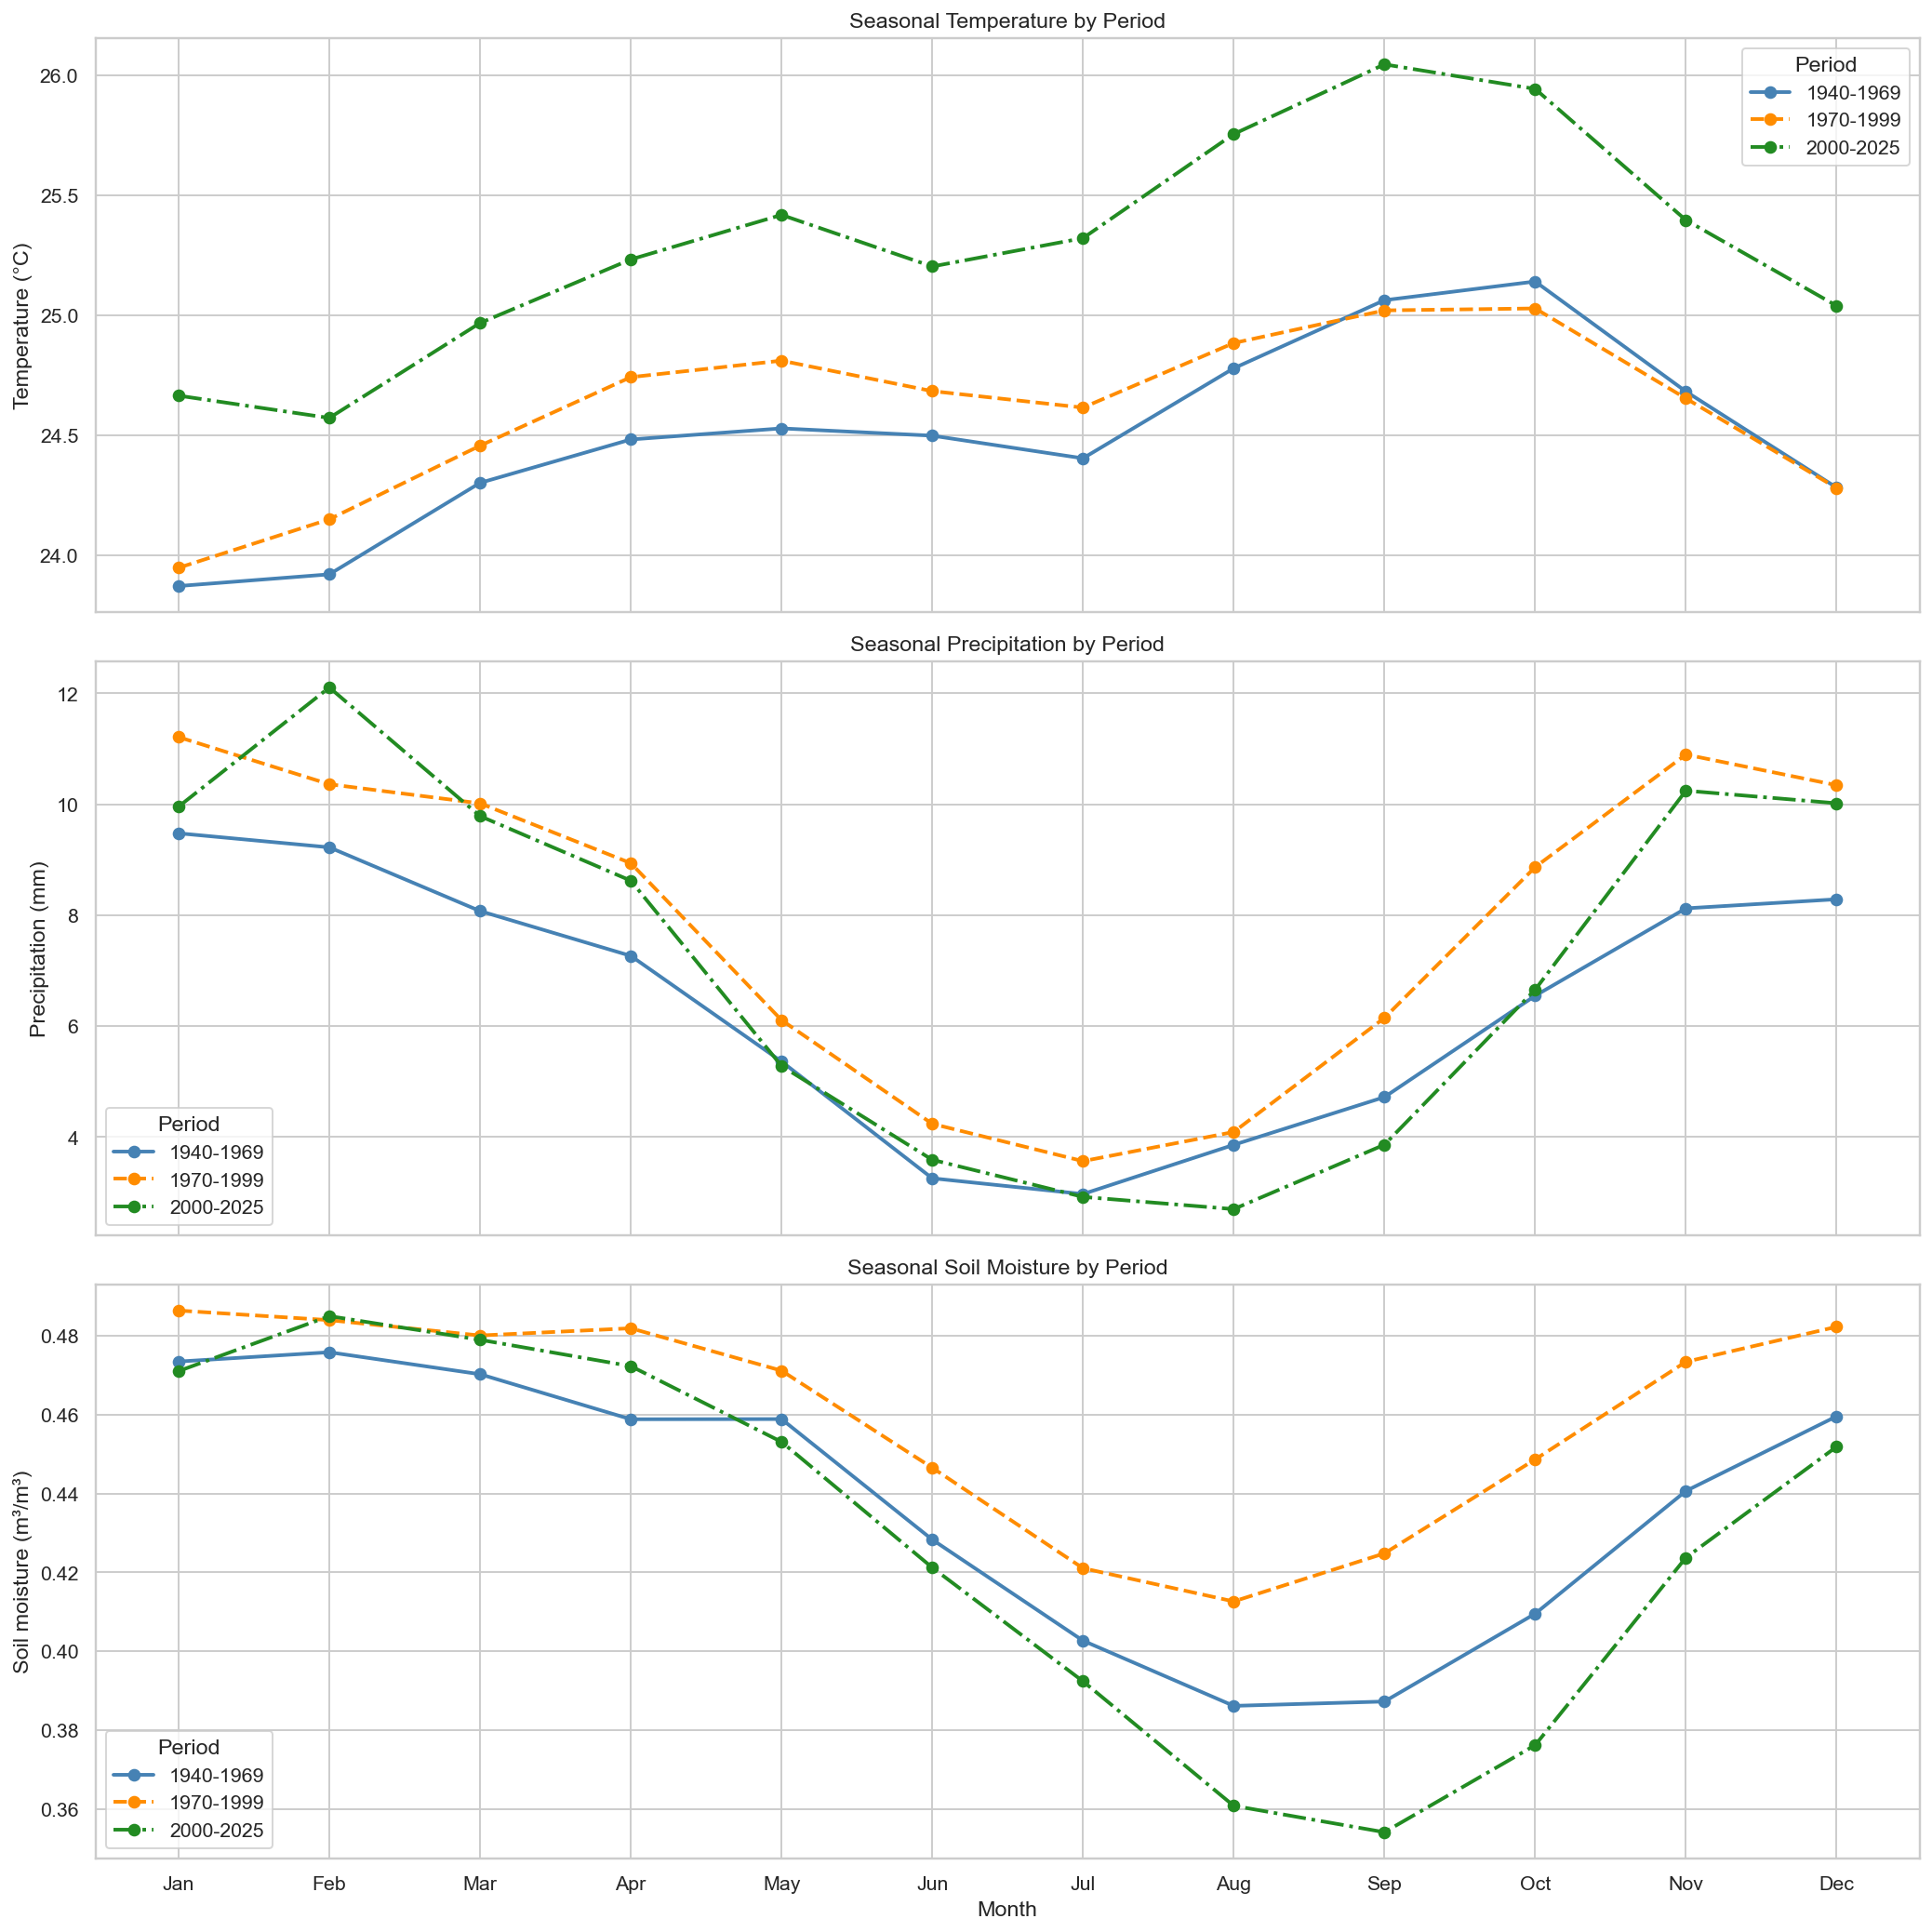

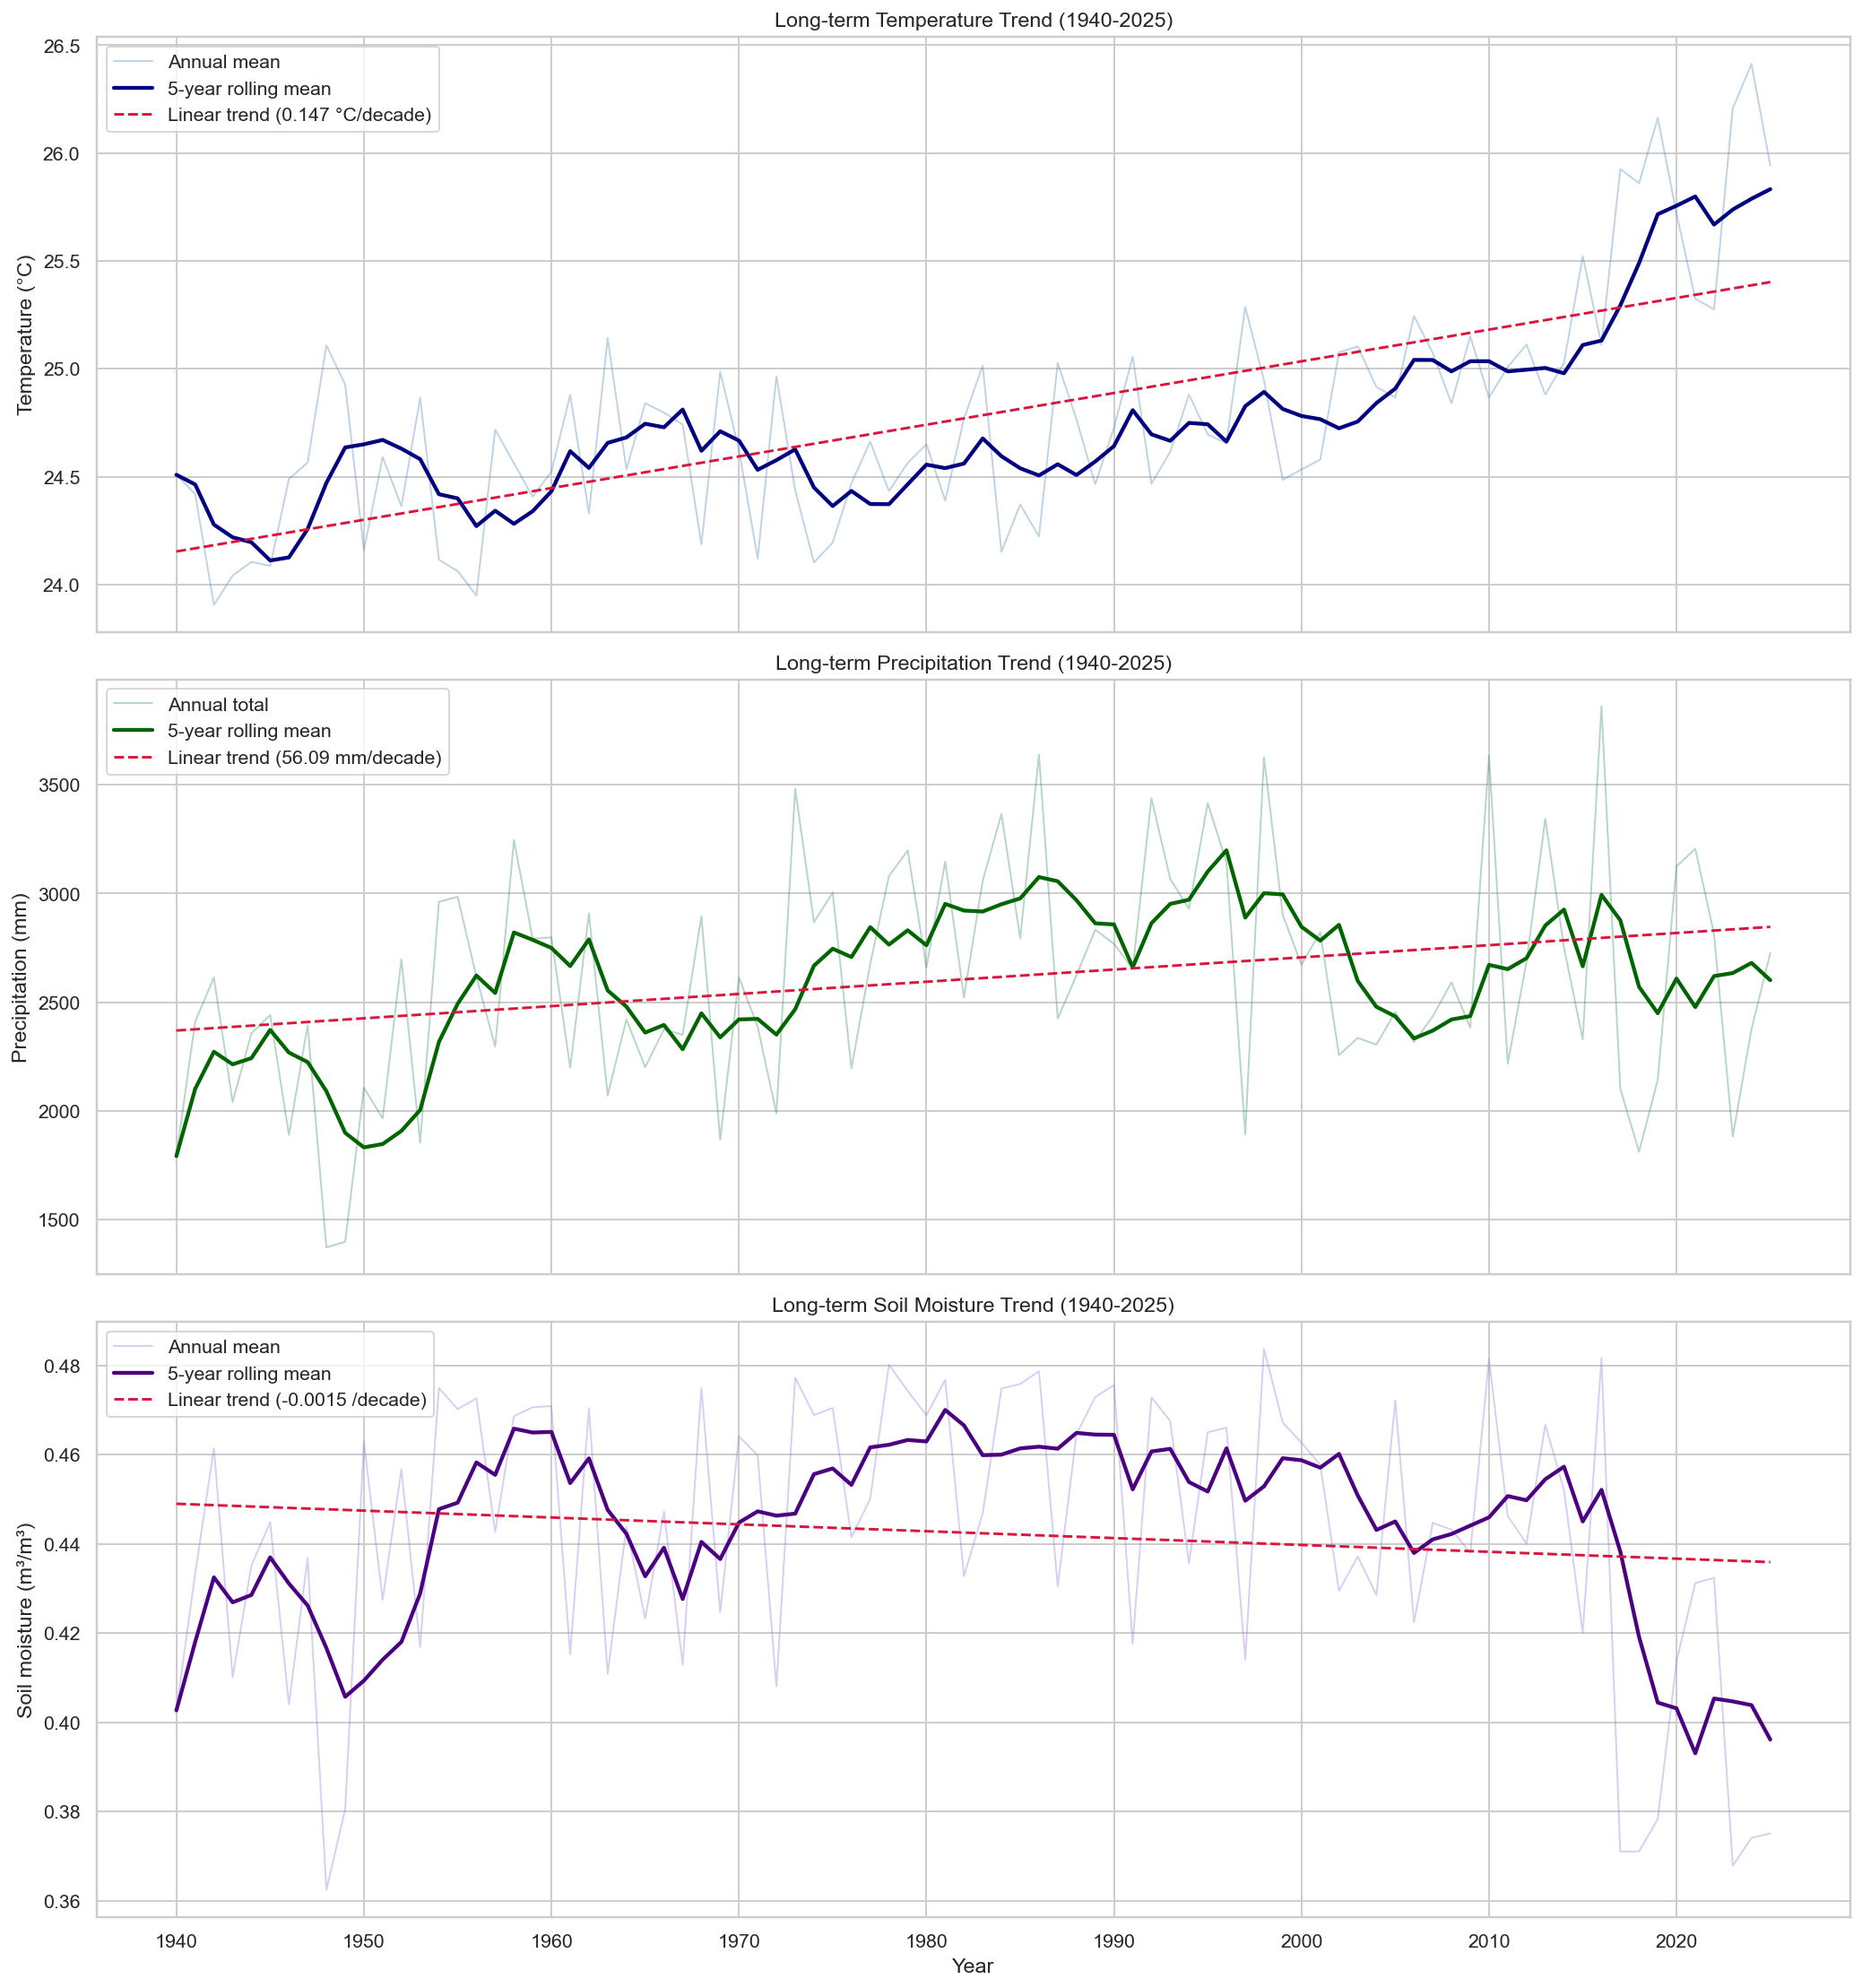


=== Stationarity Check (Monthly Series) ===


,series,adf_pvalue_raw,kpss_pvalue_raw,stationary_raw,adf_pvalue_diff1,kpss_pvalue_diff1,stationary_diff1
0,temperature_2m_mean (°C),0.321843,0.010000,False,0.0,0.1,True
1,temperature_2m_max (°C),0.053289,0.010000,False,0.0,0.1,True
2,temperature_2m_min (°C),0.689990,0.010000,False,0.0,0.1,True
3,precipitation_sum (mm),0.000257,0.010000,False,0.0,0.1,True
4,soil_moisture_0_to_100cm_mean (m³/m³),0.033447,0.010115,False,0.0,0.1,True


In [41]:
import warnings

from IPython.display import display
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings('ignore', category=InterpolationWarning)

SOIL_MOISTURE_VARIABLE = 'soil_moisture_0_to_100cm_mean (m³/m³)'
KEY_VARIABLES = [
    'temperature_2m_mean (°C)',
    'temperature_2m_max (°C)',
    'temperature_2m_min (°C)',
    'precipitation_sum (mm)',
    SOIL_MOISTURE_VARIABLE,
]
MODEL_GRANULARITY = 'monthly'

print('=== Key Variables ===')
for variable in KEY_VARIABLES:
    if variable == SOIL_MOISTURE_VARIABLE:
        print(f'- {variable} (root-zone soil moisture proxy)')
    else:
        print(f'- {variable}')

print(f'\n=== Modeling Decision ===')
print(f'Use {MODEL_GRANULARITY} aggregation for forecasting. Daily data is used only for aggregation and quality checks.')

monthly_agg = df[KEY_VARIABLES].resample('MS').agg({
    'temperature_2m_mean (°C)': 'mean',
    'temperature_2m_max (°C)': 'mean',
    'temperature_2m_min (°C)': 'mean',
    'precipitation_sum (mm)': 'sum',
    SOIL_MOISTURE_VARIABLE: 'mean',
}).dropna(how='all')

annual_agg = monthly_agg.resample('YS').agg({
    'temperature_2m_mean (°C)': 'mean',
    'temperature_2m_max (°C)': 'mean',
    'temperature_2m_min (°C)': 'mean',
    'precipitation_sum (mm)': 'sum',
    SOIL_MOISTURE_VARIABLE: 'mean',
}).dropna(how='all')

trend_rows = []
for variable in KEY_VARIABLES:
    series = annual_agg[variable].dropna().astype(float)
    years = series.index.year.to_numpy(dtype=float)
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, series.to_numpy(dtype=float))
    trend_rows.append({
        'variable': variable,
        'slope_per_year': slope,
        'slope_per_decade': slope * 10,
        'r_value': r_value,
        'p_value': p_value,
    })

trend_df = pd.DataFrame(trend_rows)
print('\n=== Long-term Trend Summary (Annual Series) ===')
display(trend_df.round(6))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
seasonal_cycle = monthly_agg.copy()
seasonal_cycle['month'] = seasonal_cycle.index.month
seasonal_means = seasonal_cycle.groupby('month')[KEY_VARIABLES].mean().reindex(range(1, 13))

fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True)

axes[0].plot(month_names, seasonal_means['temperature_2m_mean (°C)'], marker='o', linewidth=2.2, color='steelblue', label='Mean temperature')
axes[0].plot(month_names, seasonal_means['temperature_2m_max (°C)'], marker='o', linewidth=1.8, color='tomato', label='Max temperature')
axes[0].plot(month_names, seasonal_means['temperature_2m_min (°C)'], marker='o', linewidth=1.8, color='slategray', label='Min temperature')
axes[0].set_title('Seasonal Temperature Cycle (Monthly Averages)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()

axes[1].bar(month_names, seasonal_means['precipitation_sum (mm)'], color='seagreen', alpha=0.85)
axes[1].set_title('Seasonal Precipitation Cycle (Monthly Averages)')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].set_xlabel('Month')

axes[2].plot(month_names, seasonal_means[SOIL_MOISTURE_VARIABLE], marker='o', linewidth=2.0, color='mediumpurple', label='Soil moisture')
axes[2].set_title('Seasonal Soil Moisture Cycle (Monthly Averages)')
axes[2].set_ylabel('Soil moisture (m³/m³)')
axes[2].set_xlabel('Month')
axes[2].legend()

fig.tight_layout()
plt.show()

seasonal_periods = {
    '1940-1969': ('1940-01-01', '1969-12-31'),
    '1970-1999': ('1970-01-01', '1999-12-31'),
    '2000-2025': ('2000-01-01', '2025-12-31'),
}
seasonal_period_means = {}
for label, (start_date, end_date) in seasonal_periods.items():
    period_frame = df.loc[start_date:end_date, KEY_VARIABLES].copy()
    period_frame['month'] = period_frame.index.month
    seasonal_period_means[label] = period_frame.groupby('month')[KEY_VARIABLES].mean().reindex(range(1, 13))

fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharex=True)
period_styles = {
    '1940-1969': {'color': 'steelblue', 'linestyle': '-'},
    '1970-1999': {'color': 'darkorange', 'linestyle': '--'},
    '2000-2025': {'color': 'forestgreen', 'linestyle': '-.'},
}

for label, style in period_styles.items():
    axes[0].plot(month_names, seasonal_period_means[label]['temperature_2m_mean (°C)'], marker='o', linewidth=2.0, label=label, **style)
axes[0].set_title('Seasonal Temperature by Period')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(title='Period')

for label, style in period_styles.items():
    axes[1].plot(month_names, seasonal_period_means[label]['precipitation_sum (mm)'], marker='o', linewidth=2.0, label=label, **style)
axes[1].set_title('Seasonal Precipitation by Period')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend(title='Period')

for label, style in period_styles.items():
    axes[2].plot(month_names, seasonal_period_means[label][SOIL_MOISTURE_VARIABLE], marker='o', linewidth=2.0, label=label, **style)
axes[2].set_title('Seasonal Soil Moisture by Period')
axes[2].set_ylabel('Soil moisture (m³/m³)')
axes[2].set_xlabel('Month')
axes[2].legend(title='Period')

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(15, 16), sharex=True)

annual_temp = annual_agg['temperature_2m_mean (°C)']
annual_temp_roll = annual_temp.rolling(5, min_periods=1).mean()
temp_years = annual_temp.index.year.to_numpy(dtype=float)
temp_slope, temp_intercept, temp_r_value, temp_p_value, temp_std_err = stats.linregress(temp_years, annual_temp.to_numpy(dtype=float))

axes[0].plot(annual_temp.index, annual_temp, color='steelblue', alpha=0.35, linewidth=1.0, label='Annual mean')
axes[0].plot(annual_temp_roll.index, annual_temp_roll, color='navy', linewidth=2.2, label='5-year rolling mean')
axes[0].plot(annual_temp.index, temp_intercept + temp_slope * temp_years, color='crimson', linestyle='--', linewidth=1.5, label=f'Linear trend ({temp_slope * 10:.3f} °C/decade)')
axes[0].set_title('Long-term Temperature Trend (1940-2025)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()

annual_precip = annual_agg['precipitation_sum (mm)']
annual_precip_roll = annual_precip.rolling(5, min_periods=1).mean()
precip_years = annual_precip.index.year.to_numpy(dtype=float)
precip_slope, precip_intercept, precip_r_value, precip_p_value, precip_std_err = stats.linregress(precip_years, annual_precip.to_numpy(dtype=float))

axes[1].plot(annual_precip.index, annual_precip, color='seagreen', alpha=0.35, linewidth=1.0, label='Annual total')
axes[1].plot(annual_precip_roll.index, annual_precip_roll, color='darkgreen', linewidth=2.2, label='5-year rolling mean')
axes[1].plot(annual_precip.index, precip_intercept + precip_slope * precip_years, color='crimson', linestyle='--', linewidth=1.5, label=f'Linear trend ({precip_slope * 10:.2f} mm/decade)')
axes[1].set_title('Long-term Precipitation Trend (1940-2025)')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend()

annual_soil = annual_agg[SOIL_MOISTURE_VARIABLE]
annual_soil_roll = annual_soil.rolling(5, min_periods=1).mean()
soil_years = annual_soil.index.year.to_numpy(dtype=float)
soil_slope, soil_intercept, soil_r_value, soil_p_value, soil_std_err = stats.linregress(soil_years, annual_soil.to_numpy(dtype=float))

axes[2].plot(annual_soil.index, annual_soil, color='mediumpurple', alpha=0.35, linewidth=1.0, label='Annual mean')
axes[2].plot(annual_soil_roll.index, annual_soil_roll, color='indigo', linewidth=2.2, label='5-year rolling mean')
axes[2].plot(annual_soil.index, soil_intercept + soil_slope * soil_years, color='crimson', linestyle='--', linewidth=1.5, label=f'Linear trend ({soil_slope * 10:.4f} /decade)')
axes[2].set_title('Long-term Soil Moisture Trend (1940-2025)')
axes[2].set_ylabel('Soil moisture (m³/m³)')
axes[2].set_xlabel('Year')
axes[2].legend()

fig.tight_layout()
plt.show()

def run_stationarity_tests(series):
    cleaned = series.dropna().astype(float)
    if len(cleaned) < 8 or cleaned.nunique() < 2:
        return {
            'adf_stat': np.nan,
            'adf_pvalue': np.nan,
            'kpss_stat': np.nan,
            'kpss_pvalue': np.nan,
            'stationary': False,
        }

    adf_stat, adf_pvalue, _, _, _, _ = adfuller(cleaned, autolag='AIC')
    try:
        kpss_stat, kpss_pvalue, _, _ = kpss(cleaned, regression='c', nlags='auto')
    except Exception:
        kpss_stat = np.nan
        kpss_pvalue = np.nan

    return {
        'adf_stat': adf_stat,
        'adf_pvalue': adf_pvalue,
        'kpss_stat': kpss_stat,
        'kpss_pvalue': kpss_pvalue,
        'stationary': (adf_pvalue < 0.05) and (kpss_pvalue > 0.05),
    }

stationarity_rows = []
for variable in KEY_VARIABLES:
    raw_result = run_stationarity_tests(monthly_agg[variable])
    diff_result = run_stationarity_tests(monthly_agg[variable].diff().dropna())
    stationarity_rows.append({
        'series': variable,
        'adf_pvalue_raw': raw_result['adf_pvalue'],
        'kpss_pvalue_raw': raw_result['kpss_pvalue'],
        'stationary_raw': raw_result['stationary'],
        'adf_pvalue_diff1': diff_result['adf_pvalue'],
        'kpss_pvalue_diff1': diff_result['kpss_pvalue'],
        'stationary_diff1': diff_result['stationary'],
    })

stationarity_df = pd.DataFrame(stationarity_rows)
print('\n=== Stationarity Check (Monthly Series) ===')
display(stationarity_df.round(6))